In [31]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = 1000 - n_class_0

In [32]:
n_class_0,n_class_1

(900, 100)

In [33]:
[0]*10

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [34]:
# CREATE MY DATAFRAME WITH IMBALANCED DATASET-:
# np.random.normal -:Generates random numbers from a normal (Gaussian) distribution.
# In np.random.normal(loc, scale, size):
# loc → Mean (center of the distribution)
# scale → Standard deviation (spread of the distribution)
# In short:
# loc = mean, scale = standard deviation
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target':[0]*n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target':[1]*n_class_1
})

In [39]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [40]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [41]:
df.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


<Axes: xlabel='feature_1', ylabel='Count'>

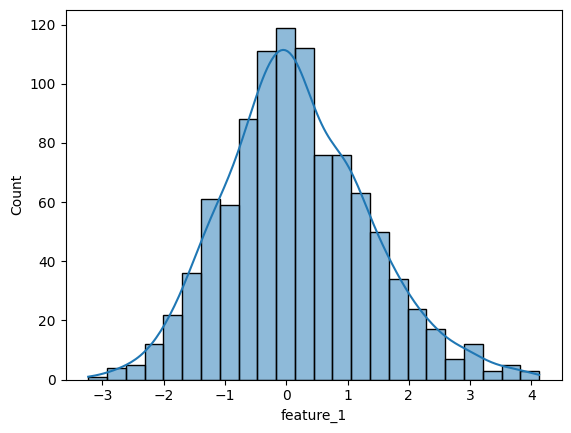

In [45]:
import seaborn as sns
sns.histplot(df["feature_1"],kde=True)

In [46]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [50]:
# UPSAMPLING
df_minority = df[df["target"]==1]
df_majority = df[df["target"]==0]

In [ ]:
from sklearn.utils import resample
# This code upsamples the minority class by randomly copying its rows (with replacement) until it becomes the same size as the majority class.
df_minority_upsampled = resample(df_minority,
                                 replace=True,                                   # replace=True means: sampling with replacement.
                                # Simple words:
                                # The same row can be selected more than once.
                                # (used in upsampling).
                                 n_samples=len(df_majority),
                                 random_state=42
                                  )

In [56]:
df_minority_upsampled.shape

(900, 3)

In [61]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled]).reset_index(drop=True)

In [65]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [74]:
# Downsampling-:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [84]:
from sklearn.utils import resample
# This code upsamples the minority class by randomly copying its rows (with replacement) until it becomes the same size as the majority class.
df_majority_downsampled = resample(df_majority,
                                 replace=False ,
                                #  Downsampling uses replace=False because we remove extra data, not duplicate it.
                                 n_samples=len(df_minority),
                                 random_state=42
                                  )

# This code downsamples the majority class by randomly selecting unique rows until its size matches the minority class.

In [85]:
# replace=False
# 👉 Sampling without replacement

# Meaning:
# No row is repeated
# Each selected row is unique

In [86]:
df_majority_downsampled.reset_index(drop=True)

,feature_1,feature_2,target
0,0.468439,1.720920,0
1,1.089165,-0.464899,0
2,0.753869,-0.969798,0
3,0.588686,-0.704720,0
4,0.283627,1.012868,0
...,...,...,...
95,-0.168426,0.553775,0
96,-0.403366,0.081491,0
97,-0.269293,0.611238,0
98,-0.295829,0.671673,0


In [87]:
df_majority_downsampled.shape

(100, 3)

In [88]:
df_downsampled = pd.concat([df_minority,df_majority_downsampled])

In [93]:
df_downsampled.reset_index(drop=True)

,feature_1,feature_2,target
0,1.699768,2.139033,1
1,1.367739,2.025577,1
2,1.795683,1.803557,1
3,2.213696,3.312255,1
4,3.033878,3.187417,1
...,...,...,...
195,-0.168426,0.553775,0
196,-0.403366,0.081491,0
197,-0.269293,0.611238,0
198,-0.295829,0.671673,0


In [94]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

Downsampling is BAD cause we are Losing the Data Points here.
So; Instead we should do UPSAMPLING cause we will not LOOSE datapoints as data points will be increasing.